                             Stacking (FNN + XGBoost) with higher order color indices Prediction

In [1]:
import pandas as pd
import numpy as np
import joblib
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
df_new = pd.read_csv(r"C:\Users\PIYUSH\Downloads\MyTable_2_TwinkleKashyap.csv")

In [3]:
# Basic colors
df_new['u_g'] = df_new['u'] - df_new['g']
df_new['g_r'] = df_new['g'] - df_new['r']
df_new['r_i'] = df_new['r'] - df_new['i']
df_new['i_z'] = df_new['i'] - df_new['z']

# Higher-order colors
df_new['u_r'] = df_new['u'] - df_new['r']
df_new['g_i'] = df_new['g'] - df_new['i']
df_new['r_z'] = df_new['r'] - df_new['z']

In [4]:
xgb_model = joblib.load("xgb_model.pkl")
fnn_model = keras.models.load_model("fnn_model.keras")
meta_model = joblib.load("meta_model.pkl")

features = joblib.load("features.pkl")
scaler = joblib.load("scaler.pkl")

In [5]:
X_input = df_new[features]

# scaled version 
X_scaled = scaler.transform(X_input)

In [6]:
# XGBoost probabilities
probs_xgb = xgb_model.predict_proba(X_input)

# FNN probabilities
probs_fnn = fnn_model.predict(X_scaled)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 755us/step


In [7]:
meta_input = np.hstack([probs_xgb, probs_fnn])

In [8]:
final_pred = meta_model.predict(meta_input)

# confidence from meta model
confidence = meta_model.predict_proba(meta_input).max(axis=1)

In [9]:
mapping = {0: 'Galaxy', 1: 'QSO', 2: 'Star'}
df_new['predicted_class'] = pd.Series(final_pred).map(mapping)
df_new['confidence'] = confidence

In [10]:
print(df_new[['predicted_class', 'confidence']].head(10))

print("\nClass distribution:")
print(df_new['predicted_class'].value_counts())

high_conf = df_new[df_new['confidence'] > 0.9]
print("\nHigh confidence count:", len(high_conf))

  predicted_class  confidence
0            Star    0.997619
1            Star    0.997636
2            Star    0.997633
3            Star    0.997630
4            Star    0.997636
5            Star    0.997637
6            Star    0.997638
7            Star    0.997631
8            Star    0.997635
9          Galaxy    0.995329

Class distribution:
predicted_class
Galaxy    75925
QSO       14259
Star       9816
Name: count, dtype: int64

High confidence count: 98798


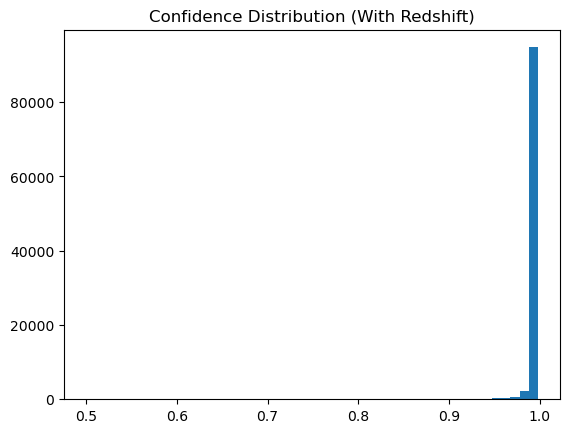

In [11]:
plt.hist(df_new['confidence'], bins=50)
plt.title("Confidence Distribution (With Redshift)")
plt.show()

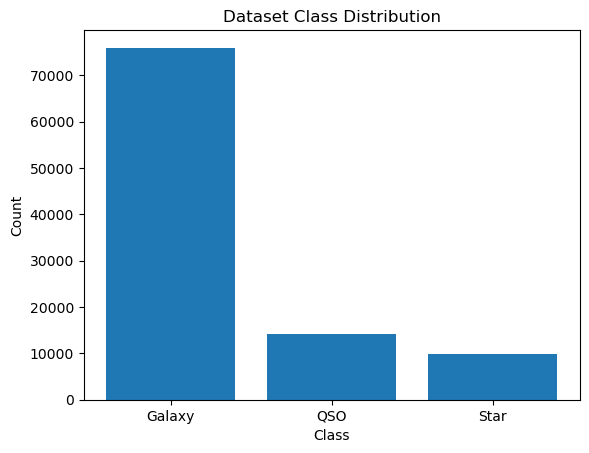

In [13]:
import matplotlib.pyplot as plt

counts = df_new['predicted_class'].value_counts()


labels = ['Galaxy', 'QSO', 'Star']
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

                                                        Without Redshift 

In [14]:
xgb_model = joblib.load("xgb_model_no_z.pkl")
fnn_model = keras.models.load_model("fnn_model_no_z.keras")
meta_model = joblib.load("meta_model_no_z.pkl")

features = joblib.load("features_no_z.pkl")
scaler = joblib.load("scaler_no_z.pkl")


In [15]:
X_input = df_new[features]

# scaling
X_scaled = scaler.transform(X_input)

In [16]:
# XGB
probs_xgb = xgb_model.predict_proba(X_input)

# FNN
probs_fnn = fnn_model.predict(X_scaled)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 724us/step


In [17]:
meta_input = np.hstack([probs_xgb, probs_fnn])

In [18]:
final_pred_no_z = meta_model.predict(meta_input)
confidence_no_z = meta_model.predict_proba(meta_input).max(axis=1)

In [19]:
mapping = {0: 'Galaxy', 1: 'QSO', 2: 'Star'}

df_new['predicted_class_no_z'] = pd.Series(final_pred_no_z).map(mapping)
df_new['confidence_no_z'] = confidence_no_z

In [20]:
print(df_new[['predicted_class_no_z', 'confidence_no_z']].head(10))

print("\nClass distribution:")
print(df_new['predicted_class_no_z'].value_counts())

high_conf = df_new[df_new['confidence_no_z'] > 0.9]
print("\nHigh confidence count:", len(high_conf))

  predicted_class_no_z  confidence_no_z
0                 Star         0.974441
1                 Star         0.975521
2                 Star         0.975484
3                 Star         0.975300
4                 Star         0.976722
5                 Star         0.976247
6                 Star         0.976506
7                 Star         0.719816
8                 Star         0.970641
9               Galaxy         0.970335

Class distribution:
predicted_class_no_z
Galaxy    74677
QSO       12842
Star      12481
Name: count, dtype: int64

High confidence count: 85394


In [21]:
print("\nComparison:")
print("With Z high confidence:", (df_new['confidence'] > 0.9).sum())
print("Without Z high confidence:", (df_new['confidence_no_z'] > 0.9).sum())


Comparison:
With Z high confidence: 98798
Without Z high confidence: 85394


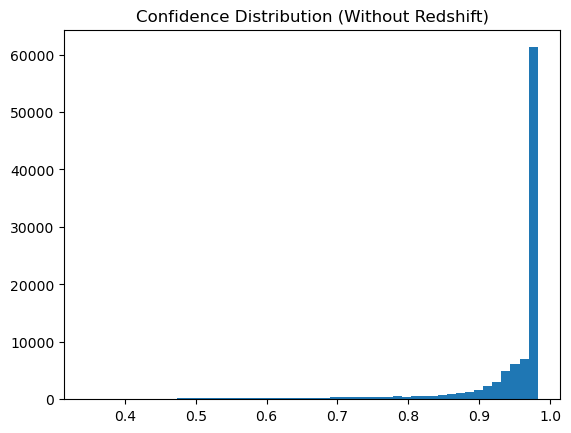

In [22]:
plt.hist(df_new['confidence_no_z'], bins=50)
plt.title("Confidence Distribution (Without Redshift)")
plt.show()

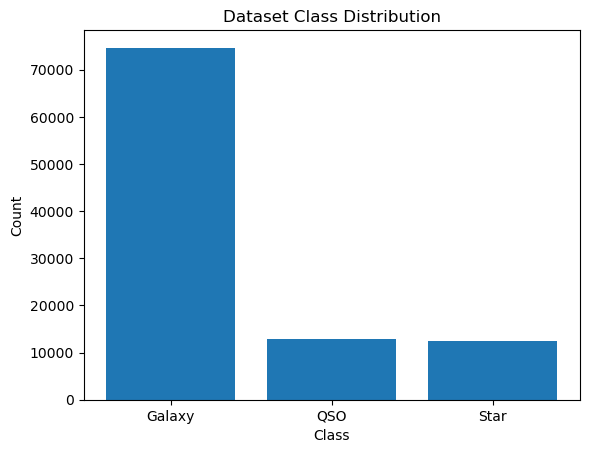

In [23]:
counts = df_new['predicted_class_no_z'].value_counts()


labels = ['Galaxy', 'QSO', 'Star']
values = [counts[label] for label in labels]

plt.bar(labels, values)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()